In [1]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

In [4]:
models_to_plot = ["GRU-256", "LSTM-256", "RNN-256", "TRF-256"] 
ll_to_show = ['3', '4', '5', '6', '7', '8', '9']

# Human Baseline (List Lengths 3, 4, 5, 6)
human_vsr_baseline = {
    '3': [7.16/8, 6.8/8, 6.9/8], 
    '4': [6.35/8, 5.25/8, 4.8/8, 6.05/8],
    '5': [5.5/8, 4.3/8, 4.2/8, 3.6/8, 5/8], 
    '6': [5.1/8, 4.25/8, 3.55/8, 3.5/8, 2.9/8, 3.95/8]
}

C:\Users\William\AppData\Local\Temp\ipykernel_33136\3017939360.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('viridis_r')(np.linspace(0.1, 0.9, len(ll_to_show)))
C:\Users\William\AppData\Local\Temp\ipykernel_33136\3017939360.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Generated analysis for: GRU-256


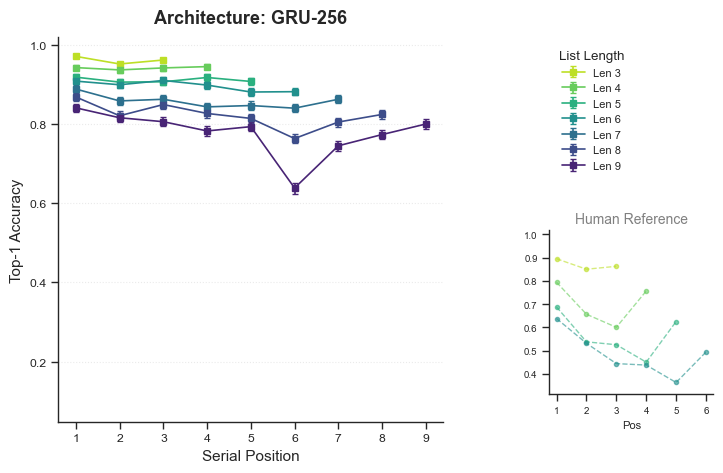

Generated analysis for: LSTM-256


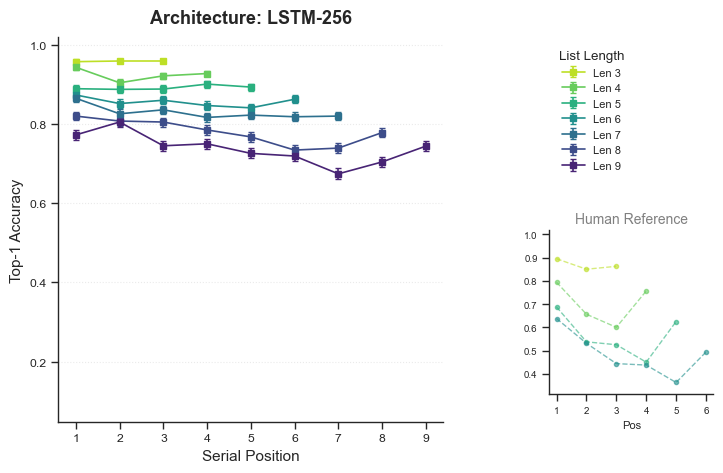

Generated analysis for: RNN-256


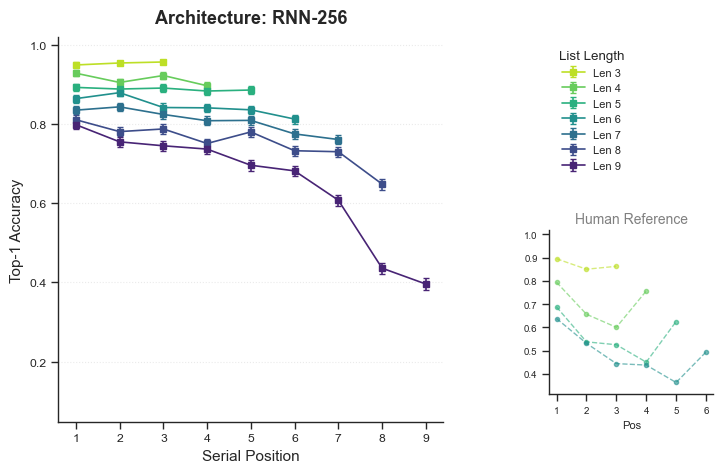

Generated analysis for: TRF-256


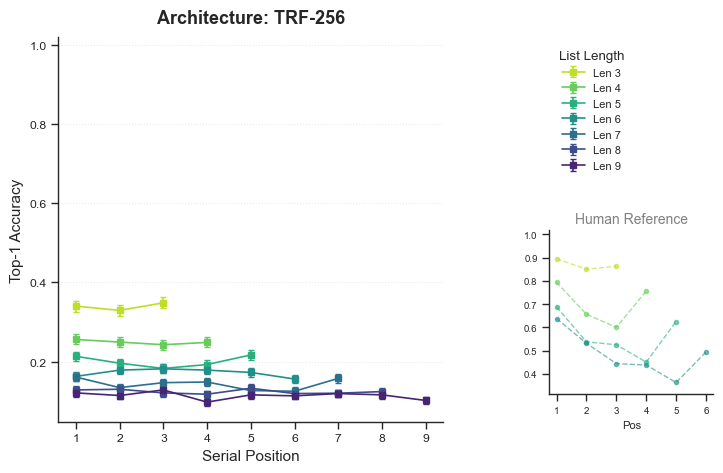

In [5]:
# Data Extraction 
all_model_data = {}
all_accuracies = [] 
human_accuracies = [val for sublist in human_vsr_baseline.values() for val in sublist]

for m_name in models_to_plot:
    try:
        # Check both the subfolder and local folder for the JSON
        paths = [f"WM_Bench/{m_name}/output/test_acc_results.json", "test_acc_results.json"]
        results = None
        for p in paths:
            try:
                with open(p, "r") as f:
                    results = json.load(f)
                    break
            except FileNotFoundError:
                continue
        
        if results is None:
            print(f"Skipping {m_name}: JSON not found.")
            continue

        m_vsr = {} 
        for key, val in results.items():
            # Robust key matching for both naming conventions
            if ("VSR_Task_list_length_" in key) and ("serial_position_" in key):
            
                ll = key.split("list_length_")[1].split("_")[0]
                sp = key.split("serial_position_")[1].split("_")[0]
        
                
                if ll in ll_to_show:
                    acc = val[0] / val[1]
                    if ll not in m_vsr: m_vsr[ll] = [[], [], []]
                    m_vsr[ll][0].append(int(sp))
                    m_vsr[ll][1].append(acc)
                    m_vsr[ll][2].append(np.sqrt((acc * (1 - acc)) / val[1]))
                    all_accuracies.append(acc)
        all_model_data[m_name] = m_vsr
    except Exception as e:
        print(f"Error processing {m_name}: {e}")

# Global scaling limits
y_min_model = min(all_accuracies) - 0.05 if all_accuracies else 0.4
y_min_human = min(human_accuracies) - 0.05 if human_accuracies else 0.3
colors = cm.get_cmap('viridis_r')(np.linspace(0.1, 0.9, len(ll_to_show)))

# Individual figures for each model
for m_name in all_model_data.keys():
    plt.rcParams["font.family"] = "Serif"
    sns.set_context("paper", font_scale=1.0)
    sns.set_style("ticks")

    # Model (Left) | Legend (Top Right) & Human (Bottom Right)
    fig = plt.figure(figsize=(9, 5))
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.35], height_ratios=[0.4, 0.6], wspace=0.2, hspace=0.1)

    # Primary Model Plot
    ax_m = fig.add_subplot(gs[:, 0])
    ax_m.set_box_aspect(1)
    
    m_data = all_model_data[m_name]
    for j, ll in enumerate(ll_to_show):
        if ll in m_data:
            d = m_data[ll]
            idx = np.argsort(d[0])
            ax_m.errorbar(np.array(d[0])[idx], np.array(d[1])[idx], yerr=np.array(d[2])[idx], 
                          label=f'Len {ll}', color=colors[j], 
                          fmt='-s', markersize=4, linewidth=1.2, capsize=2)

    ax_m.set_title(f"Architecture: {m_name}", fontsize=13, fontweight='bold', pad=10)
    ax_m.set_xlabel("Serial Position", fontsize=11)
    ax_m.set_ylabel("Top-1 Accuracy", fontsize=11)
    ax_m.set_xticks(range(1, 10))
    ax_m.set_ylim([y_min_model, 1.02])
    ax_m.grid(axis='y', linestyle=':', alpha=0.4)
    sns.despine(ax=ax_m)

    # Legend (Top Right)
    ax_leg = fig.add_subplot(gs[0, 1])
    ax_leg.axis('off')
    handles, labels = ax_m.get_legend_handles_labels()
    ax_leg.legend(handles, labels, title="List Length", loc='center left', frameon=False, fontsize=8)

    # Human Subgraph (Bottom Right)
    ax_h = fig.add_subplot(gs[1, 1])
    ax_h.set_box_aspect(1)
    for j, ll in enumerate(ll_to_show):
        if ll in human_vsr_baseline:
            ax_h.plot(np.arange(1, len(human_vsr_baseline[ll]) + 1), human_vsr_baseline[ll], 
                      '--o', color=colors[j], alpha=0.6, markersize=3, linewidth=1)
    
    ax_h.set_title("Human Reference", fontsize=10, color='gray', pad=5)
    ax_h.set_xlabel("Pos", fontsize=8)
    ax_h.set_xticks(range(1, 7))
    ax_h.set_ylim([y_min_human, 1.02])
    ax_h.tick_params(labelsize=7)
    sns.despine(ax=ax_h)

    # save_name = f"vsr_analysis_{m_name.lower()}.png"
    # plt.savefig(save_name, bbox_inches='tight', dpi=300)
    print(f"Generated analysis for: {m_name}")
    plt.tight_layout()
    plt.show()